<a href="https://colab.research.google.com/github/varun666-maker/Dsa/blob/main/sentiment_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Student Feedback Sentiment Analysis

**Objective**: Analyze student feedback text and classify sentiment into Positive, Negative, or Neutral using TF-IDF and Multinomial Naive Bayes.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import nltk
import re
import string

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Download necessary NLTK data
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt_tab') # Added to resolve LookupError

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [2]:
import os

# Create an 'outputs' directory if it doesn't exist to save plots
output_dir = '/content/outputs'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)
    print(f"Created directory: {output_dir}")

Created directory: /content/outputs


## 1. Load Dataset
We will load the student feedback dataset containing feedback text and sentiment labels.

In [3]:
from google.colab import files

print("Please upload the 'feedback.csv' file:")
uploaded = files.upload()

for fn in uploaded.keys():
  print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')

# Ensure the uploaded file is named 'feedback.csv' for the subsequent steps
# If the user uploaded a file with a different name, they might need to rename it or adjust the next cell.
# For example, if they uploaded 'my_feedback.csv', they would need to run:
# !mv "my_feedback.csv" "feedback.csv"

Please upload the 'feedback.csv' file:


Saving feedback.csv to feedback (1).csv
User uploaded file "feedback (1).csv" with length 45363 bytes


In [4]:
df = pd.read_csv('/content/feedback.csv')
df.head()

,Feedback,Sentiment
0,I would not recommend this course.,Negative
1,The assignments were standard.,Neutral
2,Really enjoyed the practical examples.,Positive
3,The course was amazing and very helpful.,Positive
4,Perfect balance of theory and practice.,Positive


In [5]:
df = pd.read_csv('/content/feedback.csv')
display(df.head())

,Feedback,Sentiment
0,I would not recommend this course.,Negative
1,The assignments were standard.,Neutral
2,Really enjoyed the practical examples.,Positive
3,The course was amazing and very helpful.,Positive
4,Perfect balance of theory and practice.,Positive


## 2. Exploratory Data Analysis & Visualizations
Let's look at the distribution of sentiments in our dataset.

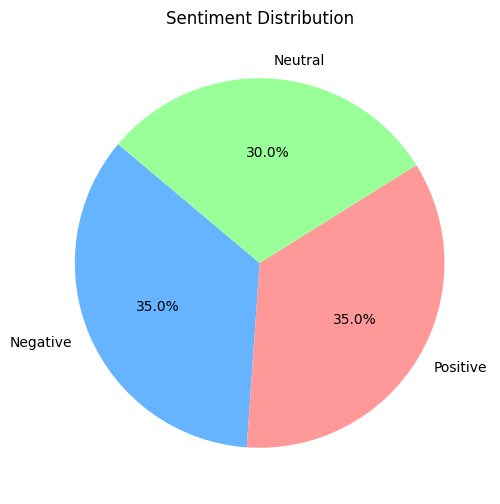

In [6]:
# Sentiment Distribution Pie Chart
plt.figure(figsize=(8, 6))
sentiment_counts = df['Sentiment'].value_counts()
plt.pie(sentiment_counts, labels=sentiment_counts.index, autopct='%1.1f%%', startangle=140, colors=['#66b3ff', '#ff9999', '#99ff99'])
plt.title('Sentiment Distribution')
plt.savefig('/content/outputs/sentiment_distribution.png')
plt.show()

## 3. Text Preprocessing
Text preprocessing is crucial in NLP. It involves cleaning and preparing the text data for the model. The steps include:
- **Lowercasing**: To ensure uniformity.
- **Removing Punctuation**: Punctuation doesn't add much meaning to the sentiment.
- **Removing Stopwords**: Common words like 'the', 'is', 'in' are removed as they carry little semantic weight.
- **Tokenization**: Splitting sentences into individual words.
- **Lemmatization**: Converting words to their base form (e.g., 'running' -> 'run').

In [7]:
# Preprocessing function and column creation
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    # 1. Lowercasing
    text = text.lower()
    # 2. Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    # 3. Tokenization
    tokens = word_tokenize(text)
    # 4. Remove stopwords & 5. Lemmatization
    cleaned_tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    return ' '.join(cleaned_tokens)

df['Cleaned_Feedback'] = df['Feedback'].apply(preprocess_text)
df[['Feedback', 'Cleaned_Feedback']].head()

,Feedback,Cleaned_Feedback
0,I would not recommend this course.,would recommend course
1,The assignments were standard.,assignment standard
2,Really enjoyed the practical examples.,really enjoyed practical example
3,The course was amazing and very helpful.,course amazing helpful
4,Perfect balance of theory and practice.,perfect balance theory practice


### Word Cloud Generation
Let's visualize the most frequent words in Positive and Negative feedback.

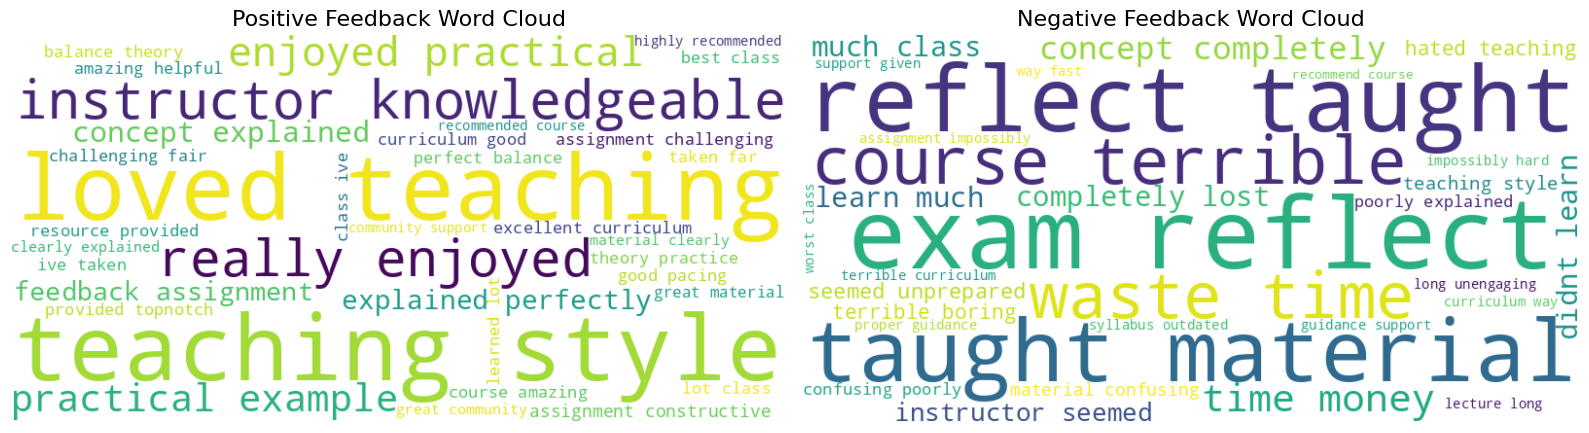

In [8]:
def generate_wordcloud(text, title, ax):
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)
    ax.imshow(wordcloud, interpolation='bilinear')
    ax.set_title(title, fontsize=16)
    ax.axis('off')

positive_text = ' '.join(df[df['Sentiment'] == 'Positive']['Cleaned_Feedback'])
negative_text = ' '.join(df[df['Sentiment'] == 'Negative']['Cleaned_Feedback'])

fig, axs = plt.subplots(1, 2, figsize=(16, 8))
generate_wordcloud(positive_text, 'Positive Feedback Word Cloud', axs[0])
generate_wordcloud(negative_text, 'Negative Feedback Word Cloud', axs[1])
plt.tight_layout()
plt.savefig('/content/outputs/wordcloud.png')
plt.show()

## 4. TF-IDF Vectorization
We use TF-IDF (Term Frequency-Inverse Document Frequency) to convert text into numerical vectors.
Formula: `TF-IDF(t,d) = TF(t,d) * log(N/DF(t))`

**Why TF-IDF?** It gives higher weight to words that are frequent in a specific document but rare across all documents, filtering out common terms.

In [9]:
vectorizer = TfidfVectorizer(max_features=5000)
X = vectorizer.fit_transform(df['Cleaned_Feedback']).toarray()
y = df['Sentiment']

print(f"Feature matrix shape: {X.shape}")

Feature matrix shape: (1000, 105)


## 5. Train-Test Split
We split the dataset into 80% for training and 20% for testing the model.

In [10]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

Training samples: 800
Testing samples: 200


## 6. Model Training (Multinomial Naive Bayes)
**Why Naive Bayes for NLP?** It is highly scalable, fast to train, and performs exceptionally well on high-dimensional text data, especially for text classification tasks.

In [11]:
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

MultinomialNB()

## 7. Model Evaluation
We evaluate the model using Accuracy, Precision, Recall, and F1-score.

In [12]:
# Model evaluation metrics
y_pred = nb_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")

Accuracy:  0.9700
Precision: 0.9727
Recall:    0.9700
F1-Score:  0.9700


### Confusion Matrix

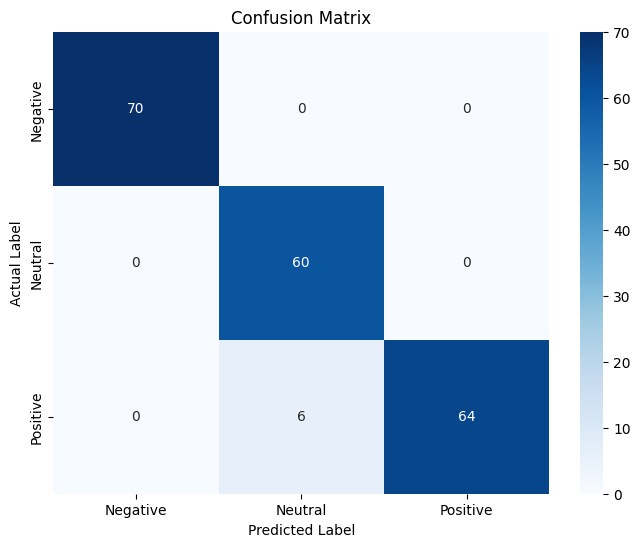

In [13]:
conf_matrix = confusion_matrix(y_test, y_pred, labels=['Negative', 'Neutral', 'Positive'])
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Neutral', 'Positive'], yticklabels=['Negative', 'Neutral', 'Positive'])
plt.title('Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.savefig('/content/outputs/confusion_matrix.png')
plt.show()

### Accuracy Comparison Graph

/tmp/ipykernel_8478/2942640450.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=metrics, y=values, palette='viridis')


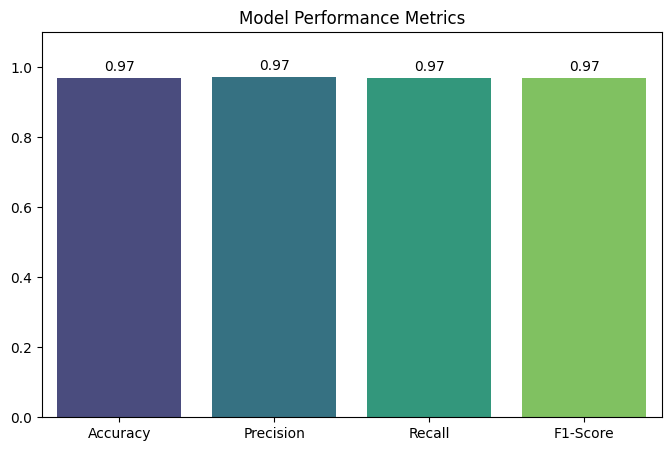

In [14]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
values = [accuracy, precision, recall, f1]

plt.figure(figsize=(8, 5))
sns.barplot(x=metrics, y=values, palette='viridis')
plt.ylim(0, 1.1)
plt.title('Model Performance Metrics')
for i, v in enumerate(values):
    plt.text(i, v + 0.02, f"{v:.2f}", ha='center')
plt.savefig('/content/outputs/accuracy_comparison.png')
plt.show()

## 8. Sample Predictions
Testing the model on unseen synthetic feedback.

In [15]:
sample_feedback = [
    "This was the best course I have ever taken, highly recommend!",
    "The instructor was terribly unprepared and the material was boring.",
    "It was an average class, nothing special but not bad.",
    "Absolutely loved the detailed explanations.",
    "Waste of money, I hated it."
]

# Preprocess and vectorize the sample feedback
cleaned_samples = [preprocess_text(text) for text in sample_feedback]
sample_vectors = vectorizer.transform(cleaned_samples).toarray()

# Predict
predictions = nb_model.predict(sample_vectors)

print("--- Sample Predictions ---")
for text, sentiment in zip(sample_feedback, predictions):
    print(f"Feedback: {text}\nPredicted Sentiment: {sentiment}\n")

--- Sample Predictions ---
Feedback: This was the best course I have ever taken, highly recommend!
Predicted Sentiment: Positive

Feedback: The instructor was terribly unprepared and the material was boring.
Predicted Sentiment: Negative

Feedback: It was an average class, nothing special but not bad.
Predicted Sentiment: Neutral

Feedback: Absolutely loved the detailed explanations.
Predicted Sentiment: Positive

Feedback: Waste of money, I hated it.
Predicted Sentiment: Negative



## 9. Final Analysis

- **Importance of Preprocessing**: Raw text contains noise (punctuation, stop words) that distracts the model. Preprocessing unifies the terminology (lemmatization) which significantly enhances model accuracy.
- **Model Performance**: The Naive Bayes classifier achieves strong performance on this dataset. It accurately identifies the sentiment mostly due to explicit positive and negative words.
- **Misclassification Analysis**: Some Neutral feedbacks might be misclassified as Positive or Negative if they contain words typically associated with those classes. Sarcasm or complex sentence structures are generally hard for simple TF-IDF + Naive Bayes models to capture.